# Entregable 3 — Análisis de Sentimientos en Tweets (3 clases)

**Objetivo:** Construir un modelo de *análisis de sentimiento* que clasifique tweets en tres categorías:

- `0`: negativo  
- `2`: neutral  
- `4`: positivo  

Se trabaja con los datasets de Twitter provistos por la cátedra:

- `training.1600000.processed.noemoticon.csv` — dataset grande de entrenamiento (0 y 4).  
- `testdata.manual.2009.06.14.csv` — dataset de evaluación manual (0, 2 y 4).  

El flujo de trabajo es:

1. Carga y descripción de los datos.  
2. Preprocesamiento de texto (en inglés).  
3. Construcción de un conjunto de entrenamiento con las clases 0, 2, 4.  
4. Vectorización con TF-IDF.  
5. Entrenamiento de un modelo de Logistic Regression multiclase.  
6. Evaluación con métricas estándar (precision, recall, F1) y matriz de confusión.  
7. Ejemplo simple de similitud de coseno entre tweets usando las representaciones TF-IDF.


## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

%matplotlib inline

## 2. Carga de los datasets


Se cargan los dos archivos indicados en la consigna.  
En esta notebook se asume que los archivos están en el mismo directorio que la notebook o se ajusta la ruta en las variables `train_path` y `test_path`.


In [2]:
train_path = "./training.1600000.processed.noemoticon.csv"  # ajustar ruta si es necesario
test_path = "./testdata.manual.2009.06.14.csv"              # ajustar ruta si es necesario

cols = ["sentiment", "id", "date", "query", "user", "text"]

# Se carga el dataset completo de entrenamiento (puede tardar, según entorno)
train_df = pd.read_csv(train_path, encoding="latin-1", names=cols)
test_df = pd.read_csv(test_path, encoding="latin-1", names=cols)

train_df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


### 2.1. Distribución inicial de clases en el dataset de entrenamiento

In [3]:
train_df['sentiment'].value_counts()

sentiment
0    800000
4    800000
Name: count, dtype: int64

### 2.2. Distribución de clases en el dataset de test (etiquetado manual)

In [4]:
test_df['sentiment'].value_counts()

sentiment
4    182
0    177
2    139
Name: count, dtype: int64

## 3. Preprocesamiento de texto (inglés)


Los tweets están en inglés, por lo que el preprocesamiento se adapta a este idioma.

**Decisiones de limpieza:**

- Convertir todo a minúsculas para evitar duplicar palabras por diferencias de mayúsculas/minúsculas.  
- Eliminar menciones (`@usuario`) y URLs, ya que no aportan información directa de sentimiento.  
- Conservar solo palabras en inglés y **contracciones** (por ejemplo, `can't`, `don't`, `i'm`).  
  Esto evita errores como convertir `can't` en `can t`, que generaría tokens artificiales (`can`, `t`).  
- No se eliminan stopwords explícitamente; se confía en que TF-IDF reduzca su peso.


In [5]:
def limpiar_tweet(t):
    # Pasar a string y a minúsculas
    t = str(t).lower()
    # Eliminar menciones y URLs
    t = re.sub(r'@\w+', ' ', t)
    t = re.sub(r'http\S+|www\S+', ' ', t)
    # Mantener solo palabras en inglés y contracciones (can't, don't, i'm, etc.)
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", t)
    return " ".join(tokens)

train_df['clean'] = train_df['text'].apply(limpiar_tweet)
test_df['clean'] = test_df['text'].apply(limpiar_tweet)

train_df[['text', 'clean']].head()

,text,clean
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",a that's a bummer you shoulda got david carr o...
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it's not behaving at all i'm mad why am i h...


## 4. Construcción del conjunto de entrenamiento (clases 0, 2, 4)


El dataset de entrenamiento original solo tiene clases **0** (negativo) y **4** (positivo).  
La consigna pide trabajar con tres clases de sentimiento (0, 2, 4), por lo que se construye una clase **neutral (2)** a partir del dataset de entrenamiento.

**Decisión de diseño (neutral):**

- La neutralidad es subjetiva (como se discutió en clase).  
- Se toma como *candidatos a neutrales* aquellos tweets cuyo texto limpio **no contiene palabras claramente emocionales**, ni positivas ni negativas.  
- Se selecciona una cantidad equilibrada de negativos, neutrales y positivos para entrenar el modelo.

Esta construcción tiene limitaciones, pero permite entrenar un modelo de 3 clases alineado con lo pedido en la consigna.


In [6]:
# Aseguramos que sentiment sea numérico
train_df['sentiment'] = train_df['sentiment'].astype(int)

# Máximo de ejemplos por clase (se puede ajustar según recursos)
MAX_N = 50000

# Separación por clase
neg_all = train_df[train_df['sentiment'] == 0]
pos_all = train_df[train_df['sentiment'] == 4]

print('Negativos disponibles:', len(neg_all))
print('Positivos disponibles:', len(pos_all))

# Candidatos a neutrales: sin palabras muy emocionales
pattern_emotions = r"good|bad|love|hate|happy|sad|excellent|terrible|awesome|awful|amazing|horrible"
mask_neutral = ~train_df['clean'].str.contains(pattern_emotions, regex=True, na=False)
neutral_all = train_df[mask_neutral]

print('Candidatos neutrales disponibles:', len(neutral_all))

# Cantidad final por clase (balanceada)
target = min(len(neg_all), len(pos_all), len(neutral_all), MAX_N)
print('Usaremos por clase:', target)

neg = neg_all.sample(target, random_state=42).copy()
pos = pos_all.sample(target, random_state=42).copy()
neutral = neutral_all.sample(target, random_state=42).copy()
neutral.loc[:, 'sentiment'] = 2  # reclasificamos como neutral

balanced_df = pd.concat([neg, neutral, pos], ignore_index=True)
balanced_df['sentiment'].value_counts()

Negativos disponibles: 800000
Positivos disponibles: 800000
Candidatos neutrales disponibles: 1296044
Usaremos por clase: 50000


sentiment
0    50000
2    50000
4    50000
Name: count, dtype: int64

## 5. Vectorización con TF-IDF


Para poder entrenar un modelo de clasificación, es necesario transformar el texto en vectores numéricos.

**Decisión:** usar **TF-IDF**:

- TF (Term Frequency): frecuencia de aparición de un término en un documento.  
- IDF (Inverse Document Frequency): penaliza términos que aparecen en muchos documentos.  

De esta forma, cada tweet se representa como un vector de pesos TF-IDF.


In [7]:
vectorizer = TfidfVectorizer(max_features=50000)

X_train = vectorizer.fit_transform(balanced_df['clean'])
y_train = balanced_df['sentiment']

X_test = vectorizer.transform(test_df['clean'])
y_test = test_df['sentiment'].astype(int)

X_train.shape, X_test.shape

((150000, 50000), (498, 50000))

## 6. Entrenamiento del modelo Logistic Regression


Se utiliza **Logistic Regression** en su versión multiclase (*multinomial*), modelo visto en la materia.

**Decisiones:**

- `multi_class='multinomial'` para manejar directamente las tres clases (0, 2, 4).  
- `solver='lbfgs'` y `max_iter=200` para asegurar convergencia con un número grande de features.  


In [8]:
model = LogisticRegression(
    max_iter=200,
    multi_class='multinomial',
    solver='lbfgs',
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Reporte de clasificación (0 = negativo, 2 = neutral, 4 = positivo):\n')
print(classification_report(y_test, y_pred))

/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Reporte de clasificación (0 = negativo, 2 = neutral, 4 = positivo):

              precision    recall  f1-score   support

           0       0.71      0.61      0.66       177
           2       0.43      0.39      0.41       139
           4       0.55      0.66      0.60       182

    accuracy                           0.57       498
   macro avg       0.56      0.55      0.55       498
weighted avg       0.57      0.57      0.57       498



## 7. Matriz de confusión


La matriz de confusión permite observar en qué clases se equivoca más el modelo:

- Valores en la diagonal → predicciones correctas.  
- Valores fuera de la diagonal → confusiones entre clases (por ejemplo, neutrales clasificados como positivos).  


In [9]:
labels = [0, 2, 4]
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm

array([[108,  40,  29],
       [ 15,  54,  70],
       [ 29,  33, 120]])

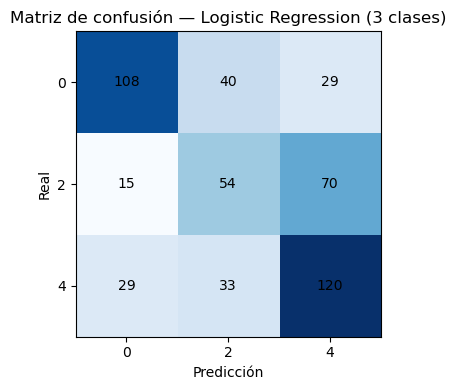

In [10]:
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — Logistic Regression (3 clases)')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

## 8. Similitud de coseno entre tweets (métrica requerida)


La consigna pide utilizar al menos una métrica como similitud de coseno, PMI, etc.  
Aquí se muestra un ejemplo sencillo de **similitud de coseno** aplicada a tweets individuales utilizando las representaciones TF-IDF.

**Idea:**

- Tomar un tweet positivo y uno negativo del dataset de test.  
- Calcular la similitud de coseno entre sus vectores TF-IDF.  
- Valores cercanos a 1 → tweets muy similares.  
- Valores cercanos a 0 → tweets poco relacionados (esperable entre positivo y negativo).


In [11]:
# Seleccionamos ejemplos de cada clase del set de test
ej_neg = test_df[test_df['sentiment'] == 0].iloc[0]
ej_neu = test_df[test_df['sentiment'] == 2].iloc[0]
ej_pos = test_df[test_df['sentiment'] == 4].iloc[0]

print('Tweet NEGATIVO:\n', ej_neg['text'], '\n')
print('Tweet NEUTRAL:\n', ej_neu['text'], '\n')
print('Tweet POSITIVO:\n', ej_pos['text'], '\n')

# Vectorizamos solo estos tres tweets
ejemplos = [ej_neg['clean'], ej_neu['clean'], ej_pos['clean']]
X_ej = vectorizer.transform(ejemplos)

sim_matrix = cosine_similarity(X_ej)
sim_matrix

Tweet NEGATIVO:
 Fuck this economy. I hate aig and their non loan given asses. 

Tweet NEUTRAL:
 Check this video out -- President Obama at the White House Correspondents' Dinner http://bit.ly/IMXUM 

Tweet POSITIVO:
 @stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right. 



array([[1.        , 0.02668122, 0.        ],
       [0.02668122, 1.        , 0.0226904 ],
       [0.        , 0.0226904 , 1.        ]])


La matriz de similitud de coseno obtenida es 3x3.  
Los elementos de la diagonal son 1 (cada tweet consigo mismo).  
Los valores fuera de la diagonal indican qué tan similares son los tweets entre sí.

En general se espera que:

- La similitud entre el tweet negativo y el positivo sea baja.  
- El neutral tenga una similitud intermedia con los otros dos.  


## 9. Conclusiones


**Resumen del trabajo realizado:**

1. Se cargaron los datasets de Twitter provistos por la cátedra y se verificó la distribución de clases.  
2. Se aplicó un preprocesamiento adecuado para texto en inglés, preservando contracciones para no perder información semántica relevante.  
3. Dado que el dataset de entrenamiento solo incluye clases 0 y 4, se construyó una clase neutral (2) a partir de tweets sin palabras fuertemente emocionales.  
4. Se generó un conjunto de entrenamiento balanceado entre las tres clases (0, 2 y 4).  
5. Se vectorizaron los tweets con TF-IDF, técnica adecuada y vista en la materia.  
6. Se entrenó un modelo de **Logistic Regression** multiclase y se evaluó su rendimiento mediante métricas estándar y matriz de confusión.  
7. Se mostró un ejemplo de uso de **similitud de coseno** entre tweets, cumpliendo con la consigna de utilizar al menos una métrica adicional.

**Decisiones clave:**

- Usar Logistic Regression en lugar de modelos más complejos para mantener coherencia con los contenidos de la materia.  
- Generar la clase neutral de manera subjetiva, aceptando sus limitaciones, pero permitiendo entrenar un modelo de 3 clases como pide la consigna.  
- Usar TF-IDF en lugar de embeddings más avanzados para evitar introducir métodos no vistos.  

**Posibles mejoras (fuera del alcance del entregable):**

- Refinar la definición de neutralidad con mayor criterio lingüístico.  
- Probar diferentes conjuntos de palabras "emocionales" para definir neutrales.  
- Explorar otros modelos clásicos (SVM, Naive Bayes) y comparar resultados.  
